START->TOPIC->LLM1(DETAIL OUTLINE)->LLM2(TOPIC+OUTLINE) DETAIL BLOG ->BLOG->END

In [53]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph,START,END
from typing import TypedDict
from dotenv import load_dotenv
load_dotenv()

True

In [54]:
llm=ChatGoogleGenerativeAI(model="gemini-3.6-flash")

In [55]:
#define State
class LLMState(TypedDict):
    topic:str
    outline:str
    blog:str
    

In [56]:
#Node 1 :For Outline of Topic
def outline(state:LLMState)->LLMState:
    topic=state["topic"]
    prompt=f"Generate The detail Outline Of Following Topic (Structure): {topic}" 
    outline=llm.invoke(prompt).content
    state["outline"]=outline
    return state

In [57]:
#Node 2 :For Generate the Blog From Outline from node 2 
def blog(state:LLMState)->LLMState:
    topic=state["topic"]
    outline=state["outline"]
    prompt=f"Generate the detail Blog on This {topic}.\n Follow This Outline For reference so help to detail blog{outline}"
    blog=llm.invoke(prompt).content
    state["blog"]=blog
    return state



In [58]:
#create graph
graph=StateGraph(LLMState)

In [59]:
#add node
graph.add_node("outline",outline)
graph.add_node("blog",blog)

In [60]:
#add edges
graph.add_edge(START,"outline")
graph.add_edge("outline","blog")
graph.add_edge("blog",END)

In [61]:
#Compilation 
blogworkflow=graph.compile()

In [62]:
#initial state
initial_state={"topic":"Bhagat Singh"}

In [63]:
#invoke
result=blogworkflow.invoke(initial_state)

In [64]:
print(result["outline"][0]["text"])

Here is a detailed, structured outline on the life, ideology, revolutionary activities, and legacy of **Bhagat Singh**.

---

# Comprehensive Outline: Bhagat Singh (1907–1931)

## I. Introduction
* **A. Hook:** Quote on revolution or sacrifice by Bhagat Singh (e.g., *"They may kill me, but they cannot kill my ideas."*)
* **B. Brief Overview:** Introduce Bhagat Singh as one of the most prominent, charismatic, and radical freedom fighters of the Indian independence movement.
* **C. Core Identity:** Beyond being a militant nationalist, he was an intellectual, a thinker, and a socialist philosopher.
* **D. Thesis Statement:** Bhagat Singh’s transition from a young nationalist to a socialist revolutionary fundamentally reshaped the Indian national movement, emphasizing that true freedom required not just political independence, but the eradication of socio-economic inequality.

---

## II. Early Life and Formative Influences (1907–1923)
* **A. Family Background and Birth:**
  1. Born on Sep

In [65]:
print(result["blog"][0]["text"])

# Beyond the Gun: The Revolutionary Life, Ideology, and Legacy of Shaheed Bhagat Singh

> *"They may kill me, but they cannot kill my ideas. They can crush my body, but they will not be able to crush my spirit."*  
> — **Bhagat Singh**

In the popular imagination of Indian history, Bhagat Singh is often remembered as the charismatic young hero with a felt hat, a sharp mustache, and a gun—a fiery patriot who met the gallows at the tender age of 23. While his courage and sacrifice are legendary, this modern iconography often overshadows the true depth of his persona. 

Bhagat Singh was not merely a militant nationalist who believed in individual acts of violence; he was an intellectual powerhouse, a voracious reader, a secular visionary, and a socialist philosopher. His transition from a passionate young nationalist to a committed socialist revolutionary fundamentally reshaped the trajectory of the Indian national movement. He proved to a subjugated nation that true freedom required far 

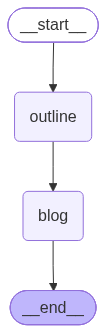

In [66]:
#visualize the workflow

from IPython.display import Image, display
# 4. Draw and display the graph
display(Image(blogworkflow.get_graph().draw_mermaid_png()))